### DATA PREPROCESSING

In [229]:
library(arrow)
library(tidyverse)

In [230]:
df <- read_parquet("data.parquet")
print(head(df))
print(colnames(df))
print(glimpse(df))

# A tibble: 6 × 11
  plate_type vehicle_manufacture vehicle_status owner_type
  <chr>      <chr>               <chr>          <chr>     
1 PRV        TOY                 ACTIVE         PERSONAL  
2 PRV        TOY                 ACTIVE         PERSONAL  
3 PRV        TOY                 ACTIVE         PERSONAL  
4 PRV        TOY                 ACTIVE         PERSONAL  
5 PRV        TOY                 ACTIVE         PERSONAL  
6 PRV        TOY                 ACTIVE         PERSONAL  
# ℹ 7 more variables: model_year <date>,
#   handicap_flag <chr>, vehicle_flag <chr>, gender <chr>,
#   nationality_group <chr>, birth_year <date>, total <int>
 [1] "plate_type"          "vehicle_manufacture"
 [3] "vehicle_status"      "owner_type"         
 [5] "model_year"          "handicap_flag"      
 [7] "vehicle_flag"        "gender"             
 [9] "nationality_group"   "birth_year"         
[11] "total"              
Rows: 266,077
Columns: 11
$ plate_type          <chr> "PRV", "PRV", "PRV", "P

In [231]:
# NA summary
na_summary <- df %>%
  summarise_all(~ sum(is.na(.))) %>% # Calculate NA count for each column
  pivot_longer(everything(), names_to = "column", values_to = "na_count") %>%
  arrange(desc(na_count))
print(na_summary)

# A tibble: 11 × 2
   column              na_count
   <chr>                  <int>
 1 vehicle_flag          266075
 2 model_year                18
 3 plate_type                 0
 4 vehicle_manufacture        0
 5 vehicle_status             0
 6 owner_type                 0
 7 handicap_flag              0
 8 gender                     0
 9 nationality_group          0
10 birth_year                 0
11 total                      0


-   `vehicle_flag` column will be dropped
-   rows with `model_year` missing will be removed

In [232]:
df <- df %>%
  select(-vehicle_flag) %>% # Drop the vehicle_flag column
  filter(!is.na(model_year)) # Remove rows with missing model_year

In [233]:
# Verify the cleaned dataset
dim(df)
glimpse(df)

Rows: 266,059
Columns: 10
$ plate_type          <chr> "PRV", "PRV", "PRV", "PRV", "PR…
$ vehicle_manufacture <chr> "TOY", "TOY", "TOY", "TOY", "TO…
$ vehicle_status      <chr> "ACTIVE", "ACTIVE", "ACTIVE", "…
$ owner_type          <chr> "PERSONAL", "PERSONAL", "PERSON…
$ model_year          <date> 2001-01-01, 2001-01-01, 2002-0…
$ handicap_flag       <chr> "NO", "NO", "NO", "NO", "NO", "…
$ gender              <chr> "MALE", "MALE", "FEMALE", "FEMA…
$ nationality_group   <chr> "QATAR", "QATAR", "ARABIC COUNT…
$ birth_year          <date> 1966-01-01, 1978-01-01, 1967-0…
$ total               <int> 17, 15, 1, 2, 1, 1, 1, 17, 13, …


In [234]:

tot_prc <- df %>%
  group_by(total) %>%
  summarise(count = n()) %>%
  mutate(percentage = count / sum(count) * 100) %>%
  arrange(desc(count)) %>%
  slice_head(n = 10)
print(tot_prc)
# histogram of total, heavy right skew
# hist(df$total, main = "Distribution of Total (filtered)", xlab = "Total", breaks = 50) 

# A tibble: 10 × 3
   total  count percentage
   <int>  <int>      <dbl>
 1     1 154750     58.2  
 2     2  41038     15.4  
 3     3  19249      7.23 
 4     4  11072      4.16 
 5     5   7431      2.79 
 6     6   5141      1.93 
 7     7   3833      1.44 
 8     8   3021      1.14 
 9     9   2292      0.861
10    10   1959      0.736


In [235]:
# top groups by total
sub_df %>% filter(total > 200)

: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `total > 200`.
[1mCaused by error:[22m
[33m![39m object 'total' not found

In [ ]:
# based on car model, gender and nationality predict the age of the driver

In [ ]:
print("Sum of total:")
print(sum(df$total))
print("Count of rows:")
print(count(df)$n)

[1] "Sum of total:"
[1] 991592
[1] "Count of rows:"
[1] 266059


In [ ]:
df <- df %>%
  uncount(total) # uncount will repeat each row according to the value in the total column

dim(df) # check

[1] 991592      9

In [ ]:
# Inspect the first few rows of the expanded dataset
head(df, 10)

# A tibble: 10 × 9
   plate_type vehicle_manufacture vehicle_status owner_type model_year
   <chr>      <chr>               <chr>          <chr>      <date>    
 1 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 2 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 3 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 4 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 5 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 6 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 7 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 8 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
 9 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
10 PRV        TOY                 ACTIVE         PERSONAL   2001-01-01
# ℹ 4 more variables: handicap_flag <chr>, gender <chr>,
#   nationality_group <chr>, birth_year <date>

In [ ]:
# Check the structure and summary of the expanded dataset
str(df)

tibble [991,592 × 9] (S3: tbl_df/tbl/data.frame)
 $ plate_type         : chr [1:991592] "PRV" "PRV" "PRV" "PRV" ...
 $ vehicle_manufacture: chr [1:991592] "TOY" "TOY" "TOY" "TOY" ...
 $ vehicle_status     : chr [1:991592] "ACTIVE" "ACTIVE" "ACTIVE" "ACTIVE" ...
 $ owner_type         : chr [1:991592] "PERSONAL" "PERSONAL" "PERSONAL" "PERSONAL" ...
 $ model_year         : Date[1:991592], format: "2001-01-01" "2001-01-01" ...
 $ handicap_flag      : chr [1:991592] "NO" "NO" "NO" "NO" ...
 $ gender             : chr [1:991592] "MALE" "MALE" "MALE" "MALE" ...
 $ nationality_group  : chr [1:991592] "QATAR" "QATAR" "QATAR" "QATAR" ...
 $ birth_year         : Date[1:991592], format: "1966-01-01" "1966-01-01" ...


In [ ]:
print(table(df$handicap_flag))
print(table(df$vehicle_status))
print(table(df$owner_type))
print(table(df$plate_type))


    NO    YES 
991155    437 

ACTIVE EXPORT SUSPEN 
929284  61720    588 

PERSONAL 
  991592 

   DIP    EQP    HEQ    PRM    PRT    PRV    PUT    TLR    TMP    TXI    XPO 
   706   1455    704  19317 133102 767166   2053   5346     12     11  61720 


In [ ]:
df <- df %>%
  filter(vehicle_status == "ACTIVE") %>%
  select(-handicap_flag, -owner_type, -vehicle_status)

head(df)

# A tibble: 6 × 7
  plate_type vehicle_manufacture model_year gender
  <chr>      <chr>               <date>     <chr> 
1 PRV        TOY                 2001-01-01 MALE  
2 PRV        TOY                 2001-01-01 MALE  
3 PRV        TOY                 2002-01-01 FEMALE
4 PRV        TOY                 2002-01-01 FEMALE
5 PRV        TOY                 2002-01-01 FEMALE
6 PRV        TOY                 2002-01-01 FEMALE
# ℹ 3 more variables: nationality_group <chr>,
#   birth_year <date>, total <int>

In [ ]:
# 2001-01-01 -> 2001 for model_year and birth_year
df <- df %>%
  mutate(model_year = as.integer(format(as.Date(model_year, format = "%Y-%m-%d"), "%Y"))) %>%
  mutate(birth_year = as.integer(format(as.Date(birth_year, format = "%Y-%m-%d"), "%Y")))

head(df)

# A tibble: 6 × 7
  plate_type vehicle_manufacture model_year gender
  <chr>      <chr>                    <int> <chr> 
1 PRV        TOY                       2001 MALE  
2 PRV        TOY                       2001 MALE  
3 PRV        TOY                       2002 FEMALE
4 PRV        TOY                       2002 FEMALE
5 PRV        TOY                       2002 FEMALE
6 PRV        TOY                       2002 FEMALE
# ℹ 3 more variables: nationality_group <chr>,
#   birth_year <int>, total <int>

In [ ]:

sub_df <- df %>%
  group_by(vehicle_manufacture) %>%
  summarise(count = n()) %>%
  arrange(desc(count)) %>%
  mutate(percentage = count / sum(count) * 100) %>%
  slice_head(n = 15)
print(sub_df, n = 15)

# A tibble: 15 × 3
   vehicle_manufacture count percentage
   <chr>               <int>      <dbl>
 1 TOY                 26621      11.3 
 2 NIS                 18769       7.98
 3 CHE                 13966       5.94
 4 MER                 12690       5.40
 5 MIT                 11003       4.68
 6 GMC                 10672       4.54
 7 HON                  8831       3.75
 8 FOR                  8221       3.50
 9 LEX                  7451       3.17
10 BMW                  7225       3.07
11 KIA                  6996       2.97
12 SUZ                  6825       2.90
13 HYU                  6380       2.71
14 VOL                  5020       2.13
15 MAZ                  4736       2.01


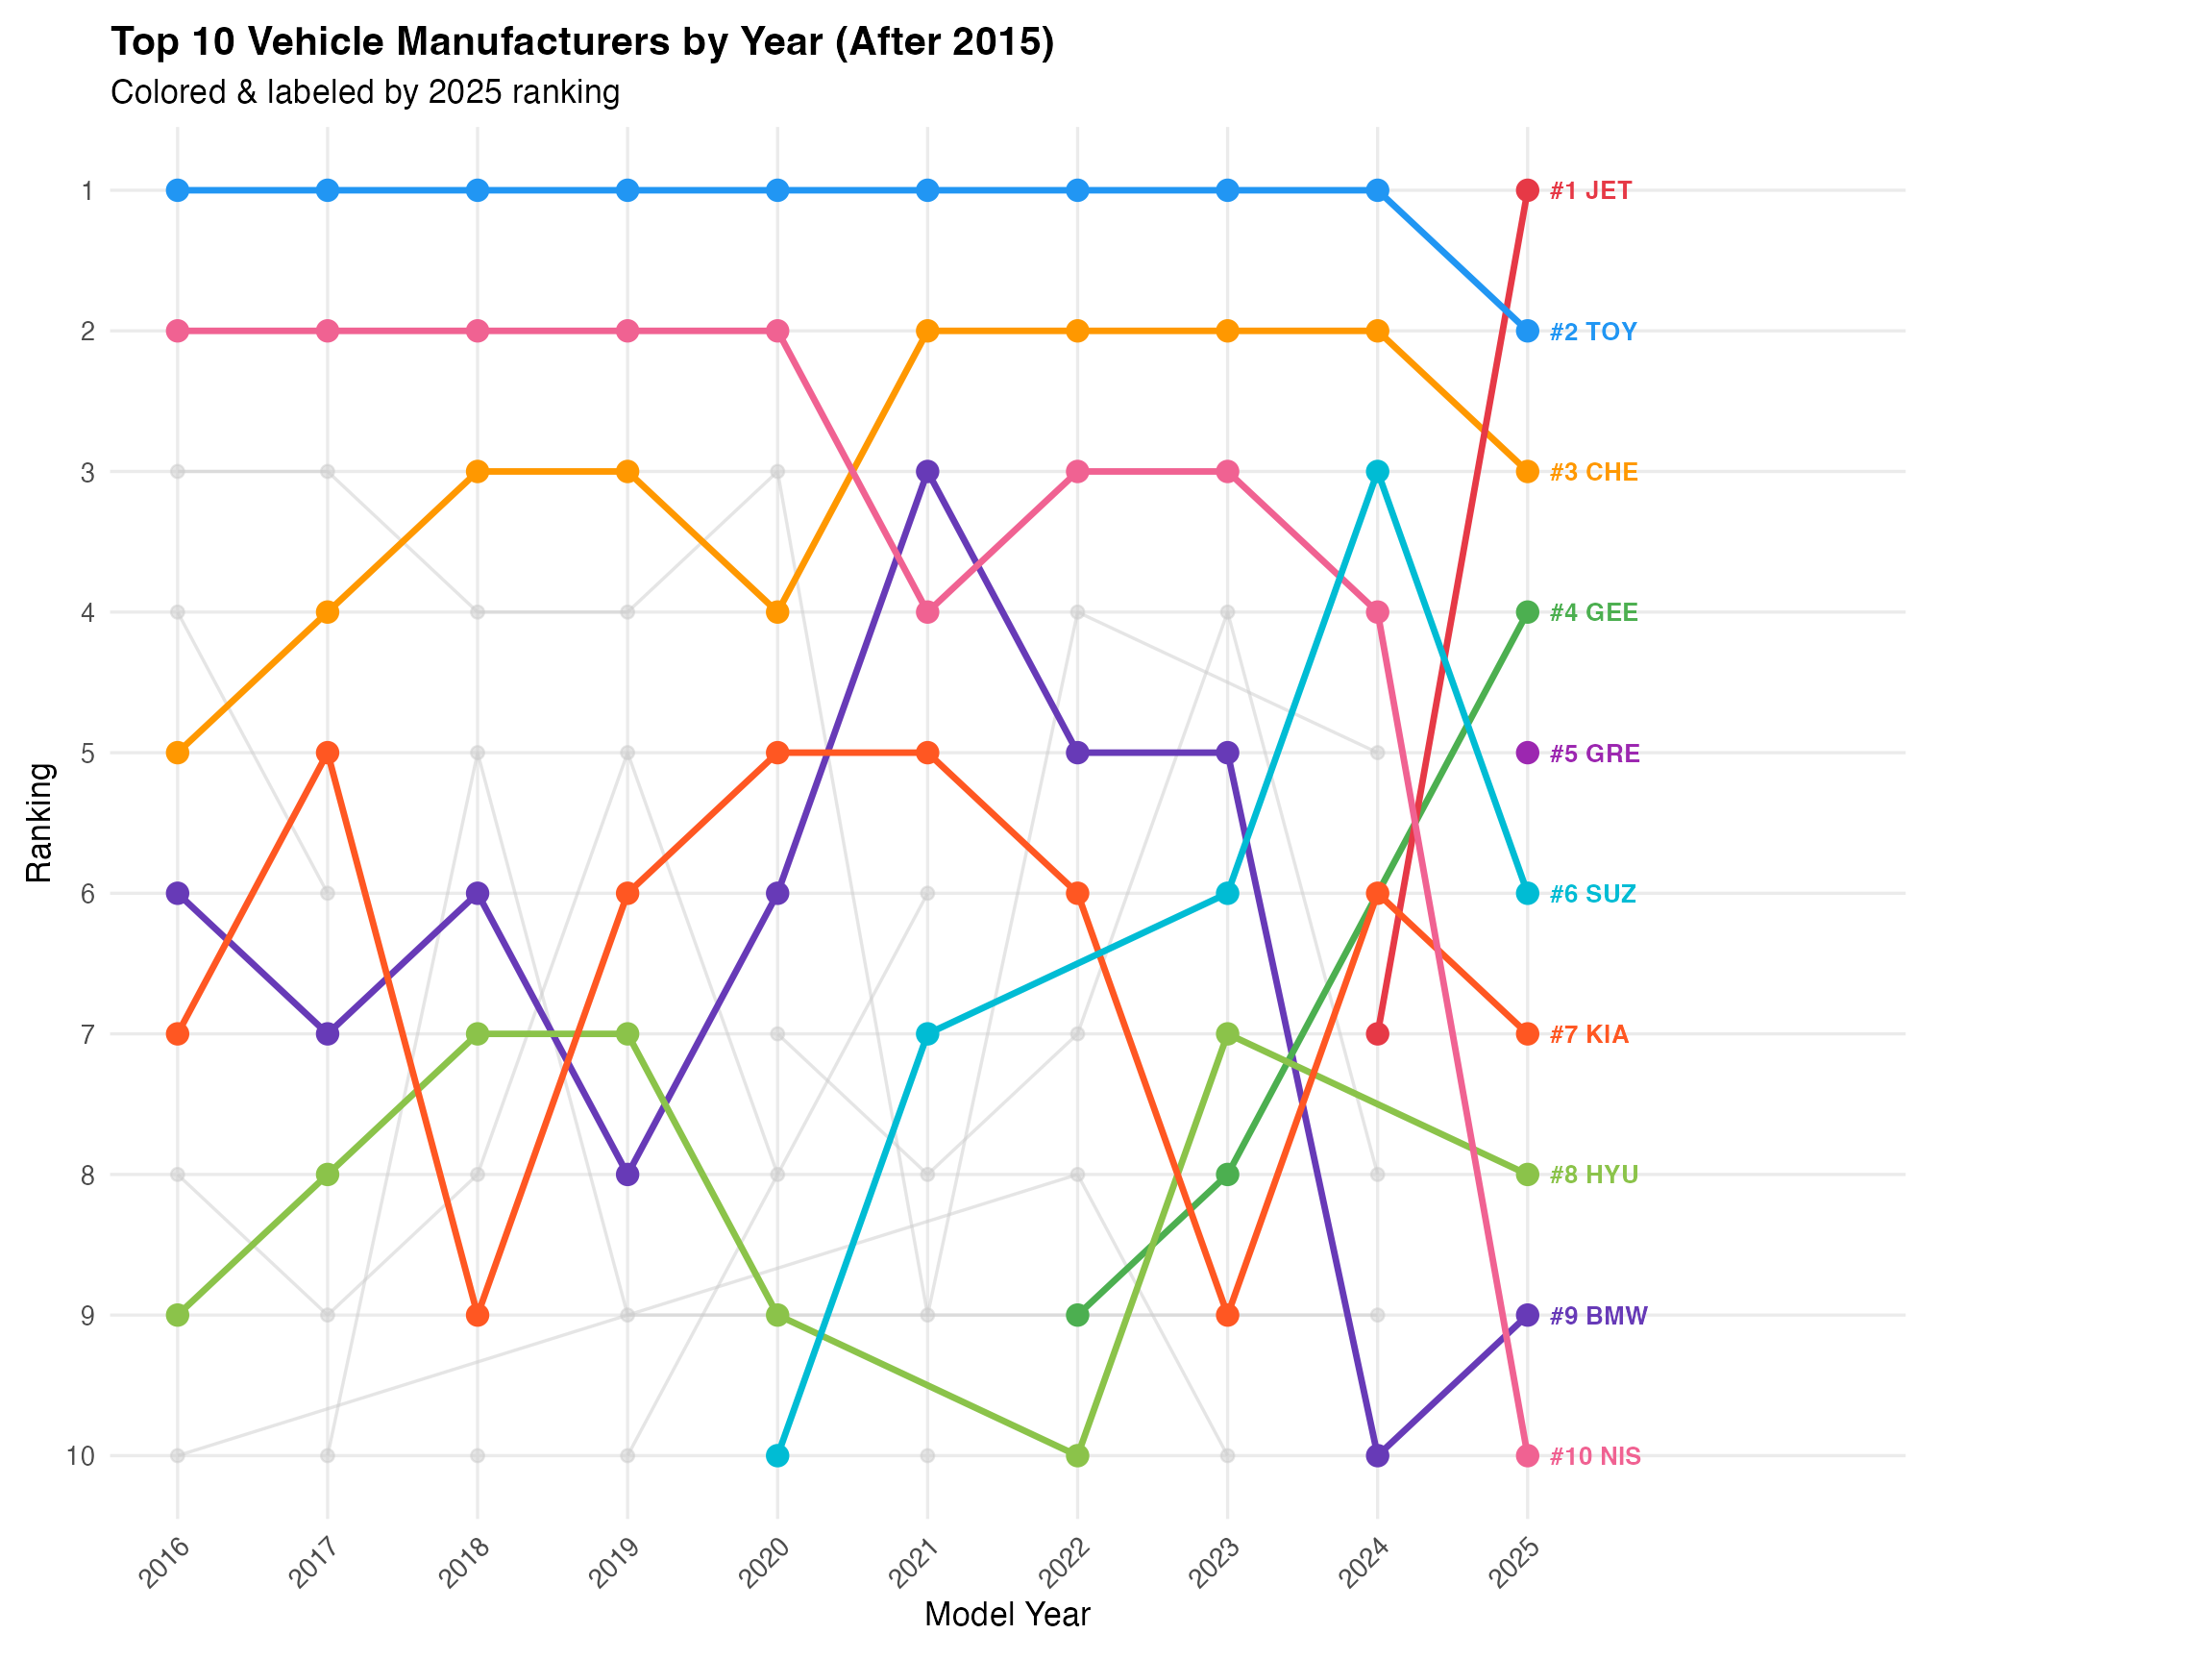

In [240]:
library(dplyr)
library(ggplot2)

# --- Data prep ---
bump_df <- df %>%
  mutate(model_year = as.integer(format(model_year, "%Y"))) %>%
  filter(model_year > 2015) %>%
  group_by(model_year, vehicle_manufacture) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(model_year, desc(count)) %>%
  group_by(model_year) %>%
  mutate(rank = row_number()) %>%
  filter(rank <= 10) %>%                           # changed 15 -> 10
  ungroup()

# --- Get top 10 manufacturers present in 2025 ---
top15_2025 <- bump_df %>%
  filter(model_year == 2025) %>%
  arrange(rank) %>%
  pull(vehicle_manufacture)

# --- Add highlight column ---
bump_df <- bump_df %>%
  mutate(highlight = ifelse(vehicle_manufacture %in% top15_2025, vehicle_manufacture, "Other"))

# --- Generate 10 distinct colors ---
top15_colors <- setNames(
  c("#E63946","#2196F3","#FF9800","#4CAF50","#9C27B0",
    "#00BCD4","#FF5722","#8BC34A","#673AB7","#F06292"),
  top15_2025
)
all_colors <- c(top15_colors, "Other" = "grey80")

# --- Labels only for top 10 in 2025 ---
label_df <- bump_df %>%
  filter(model_year == 2025, vehicle_manufacture %in% top15_2025)

# --- Plot ---
ggplot(bump_df, aes(x = model_year, y = rank, group = vehicle_manufacture)) +
  geom_line(
    data = bump_df %>% filter(highlight == "Other"),
    color = "grey80", linewidth = 0.6, alpha = 0.5
  ) +
  geom_point(
    data = bump_df %>% filter(highlight == "Other"),
    color = "grey80", size = 2, alpha = 0.5
  ) +
  geom_line(
    data = bump_df %>% filter(highlight != "Other"),
    aes(color = highlight), linewidth = 1.2
  ) +
  geom_point(
    data = bump_df %>% filter(highlight != "Other"),
    aes(color = highlight), size = 3.5
  ) +
  geom_text(
    data = label_df,
    aes(label = paste0("#", rank, " ", vehicle_manufacture), color = vehicle_manufacture),
    x = 2025.15,
    hjust = 0, size = 3.5, fontface = "bold"
  ) +
  scale_color_manual(values = all_colors) +
  scale_y_reverse(breaks = 1:10) +                 # changed 15 -> 10
  scale_x_continuous(
    breaks = unique(bump_df$model_year),
    expand = expansion(mult = c(0.05, 0.28))
  ) +
  labs(
    title = "Top 10 Vehicle Manufacturers by Year (After 2015)",
    subtitle = "Colored & labeled by 2025 ranking",
    x = "Model Year",
    y = "Ranking"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.margin = margin(10, 120, 10, 10)
  )

### Simple Random Sampling

In [244]:
# Simple random sampling to find the percentage of toyota (TOY) in the population
set.seed(123) # for reproducibility
# true proportion in the population
true_proportion <- mean(df$vehicle_manufacture == "TOY")
print(paste("True proportion of TOY in the population:", round(true_proportion * 100, 2), "%"))

[1] "True proportion of TOY in the population: 11.67 %"


In [280]:
# sample proportion for each sample size (single draw per size)
sample_sizes <- c(5, 10, 50, 100, 500, 1000)

results <- data.frame(sample_size = sample_sizes) %>%
  rowwise() %>%
  mutate(
    sample_proportion = mean(sample_n(df, sample_size, replace = TRUE)$vehicle_manufacture == "TOY")
  ) %>%
  ungroup() %>%
  mutate(bias = sample_proportion - true_proportion)

print(results)


# A tibble: 6 × 3
  sample_size sample_proportion     bias
        <dbl>             <dbl>    <dbl>
1           5             0.2    0.0833 
2          10             0.1   -0.0167 
3          50             0.04  -0.0767 
4         100             0.14   0.0233 
5         500             0.126  0.00931
6        1000             0.121  0.00431


### Stratified Sampling

In [282]:
print(table(df$nationality_group))


        AFRICA ARABIC COUNTRY           ASIA      AUSTRALIA 
          8041          68967          44227           1481 
        EUROPE           GULF  NORTH AMERICA         OTHERS 
         19295          14580           8646            752 
         QATAR  SOUTH AMERICA 
         98314           1756 


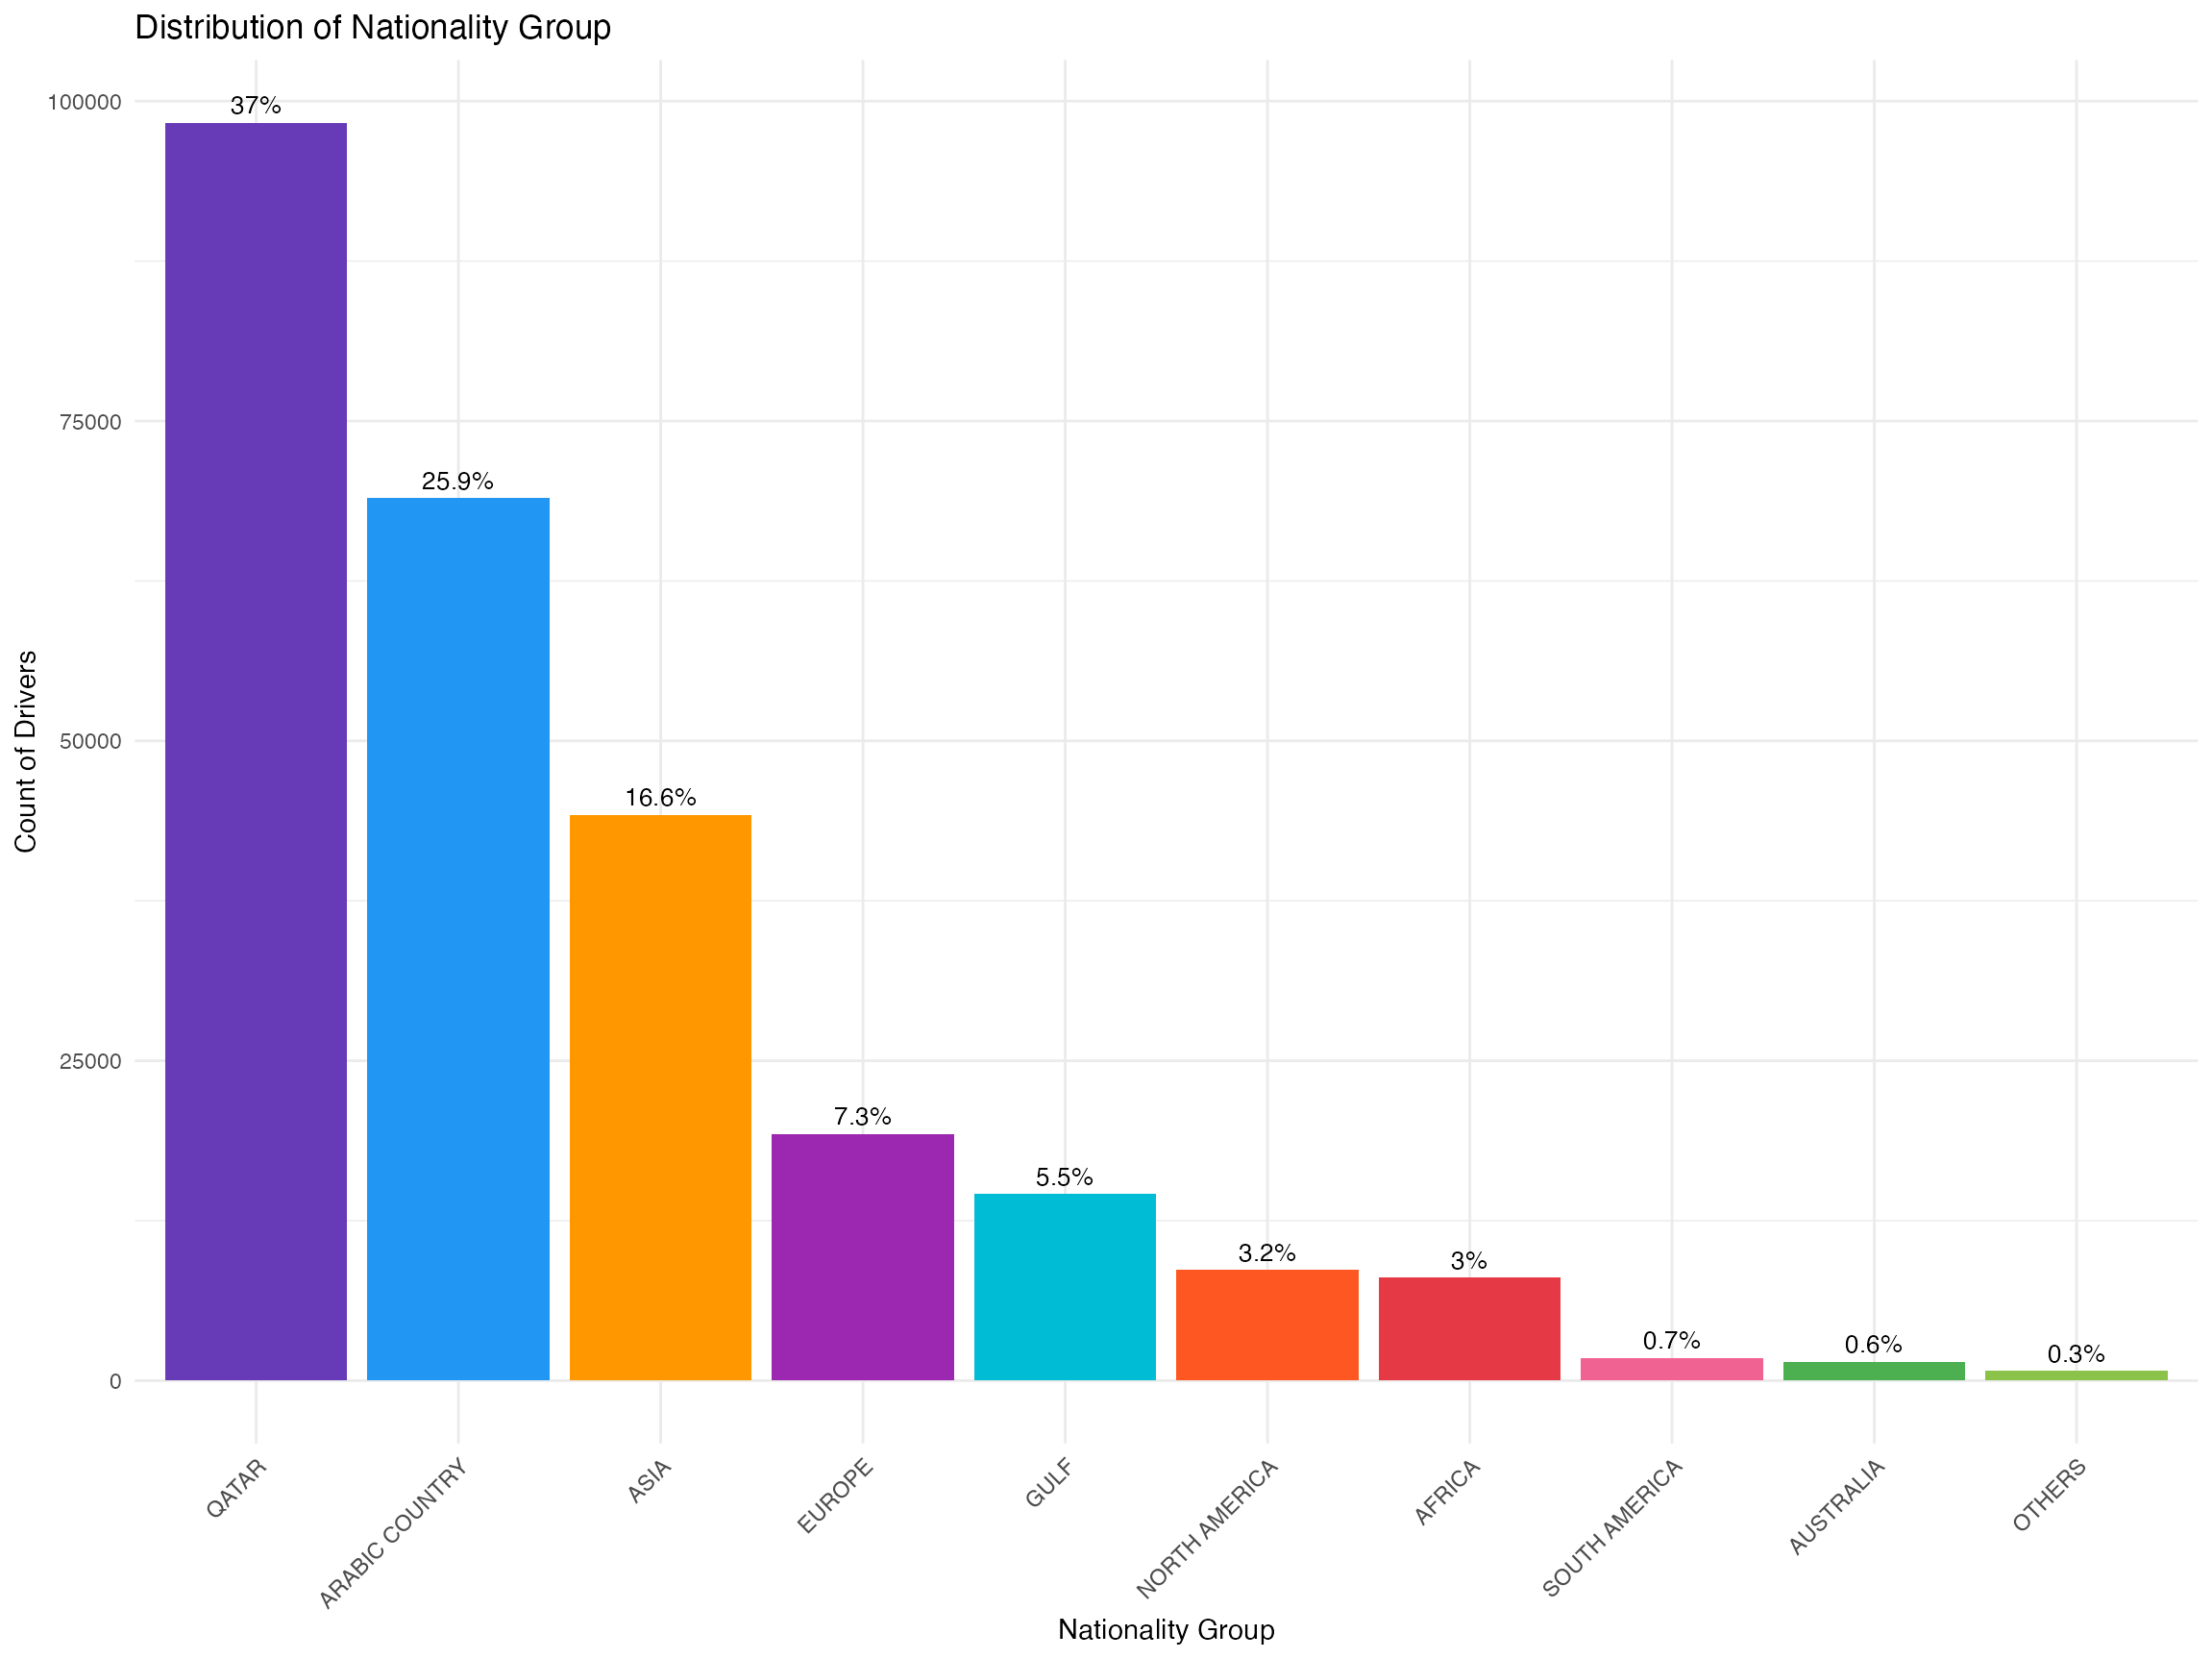

In [295]:
# bar chart of df$nationality_group
colors <- c("#E63946","#2196F3","#FF9800","#4CAF50","#9C27B0",
    "#00BCD4","#FF5722","#8BC34A","#673AB7","#F06292")

# data frame for chart, flilter and desc
chart_df <- df %>%
  group_by(nationality_group) %>%
  summarise(count = n()) %>%
  arrange(desc(count)) %>%
        mutate(percentage = count / sum(count) * 100)

# Create a bar plot of nationality and add percentage labels on top of the bars

ggplot(chart_df, aes(x = reorder(nationality_group, -count), y = count, fill = nationality_group)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(round(percentage, 1), "%")), vjust = -0.5, size = 3.5) +
  scale_fill_manual(values = colors) +
  labs(title = "Distribution of Nationality Group", x = "Nationality Group", y = "Count of Drivers") +
  theme_minimal() +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1))

In [300]:

# nationality is strata, do stratified sampling to find the percentage of TOY in the population
sample_sizes_strat <- c(5, 10, 50, 100, 500, 1000)

strat_results <- tibble(sample_size = sample_sizes_strat) %>%
  mutate(
    strat_sample = purrr::map(
      sample_size,
      ~ df %>%
        group_by(nationality_group) %>%
        sample_n(.x, replace = TRUE) %>%
        ungroup()
    ),
    sample_proportion = purrr::map_dbl(strat_sample, ~ mean(.x$vehicle_manufacture == "TOY")),
    bias = sample_proportion - true_proportion
  ) %>%
  select(-strat_sample)

print(strat_results)



# A tibble: 6 × 3
  sample_size sample_proportion     bias
        <dbl>             <dbl>    <dbl>
1           5             0.1   -0.0167 
2          10             0.12   0.00331
3          50             0.156  0.0393 
4         100             0.155  0.0383 
5         500             0.162  0.0453 
6        1000             0.159  0.0420 


### Systemic sampling

In [ ]:
# systematic sampling to find the percentage of TOY in the population circular sampling

shuffled_df <- df %>% slice_sample(prop = 1)

systematic_results <- tibble(sample_size = sample_sizes) %>%
  mutate(
    systematic_sample = purrr::map(
      sample_size,
      ~ shuffled_df %>%
        slice(seq(1, n(), by = floor(n() / .x)))
    ),
    sample_proportion = purrr::map_dbl(systematic_sample, ~ mean(.x$vehicle_manufacture == "TOY")),
    bias = sample_proportion - true_proportion
  ) %>%
  select(-systematic_sample)
print(systematic_results)

# A tibble: 6 × 3
  sample_size sample_proportion      bias
        <dbl>             <dbl>     <dbl>
1           5            0.333   0.217   
2          10            0.182   0.0651  
3          50            0.118   0.000955
4         100            0.0792 -0.0375  
5         500            0.106  -0.0109  
6        1000            0.111  -0.00580 


## Cluster Sampling

In [ ]:
# cluster sampling using nationality_group as clusters

cluster_results <- tibble(sample_size = sample_sizes) %>%
  mutate(
    cluster_sample = purrr::map(
      sample_size,
      ~ {
        cluster_sizes <- df %>%
          count(nationality_group, name = "cluster_n")

        avg_cluster_size <- mean(cluster_sizes$cluster_n)
        n_clusters <- max(1, min(nrow(cluster_sizes), ceiling(.x / avg_cluster_size)))

        selected_clusters <- cluster_sizes %>%
          slice_sample(n = n_clusters) %>%
          pull(nationality_group)

        sampled_rows <- df %>%
          filter(nationality_group %in% selected_clusters)

        if (nrow(sampled_rows) > .x) {
          sampled_rows %>% slice_sample(n = .x)
        } else {
          sampled_rows
        }
      }
    ),
    sample_proportion = purrr::map_dbl(cluster_sample, ~ mean(.x$vehicle_manufacture == "TOY")),
    bias = sample_proportion - true_proportion
  ) %>%
  select(-cluster_sample)

print(cluster_results)